# Script for scatter plot 

# Co-encapsulated K-562 and HEK293 cells

In [40]:
import pandas as pd
print("Pandas imported successfully, version: "+pd.__version__)

import numpy as np
print("Numpy imported successfully, version: "+np.__version__)


import scipy as sm
from scipy.stats import *
print("SciPy imported successfully, version: "+sm.__version__)

import seaborn as sns
print("Seaborn imported successfully, version: "+sns.__version__)
sns.set(style="whitegrid")

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

OUTPUTS_DIR ="Output/"


import warnings
warnings.filterwarnings("ignore")

sns.set_style("ticks")

Pandas imported successfully, version: 1.0.1
Numpy imported successfully, version: 1.18.1
SciPy imported successfully, version: 1.4.1
Seaborn imported successfully, version: 0.11.0


In [41]:
experiment_list = [
    
    [ "output_crops.csv", "K562 and HEK293,","30 cycles, + Nuclei"],
    
]

In [42]:
# Compensated analysis
# ACTB signal was detected in YAP channel

data_all = pd.DataFrame()

for datafile in experiment_list:
    tmp = pd.read_csv(datafile[0], sep=',')
    tmp["Cell"] = datafile[1]
    tmp["Condition"] = datafile[2]
    
    # Append the data portion to whole data structure
    data_all = data_all.append(tmp, ignore_index=True )

# Log data
actb_tmp = data_all["ACTB_mean"].copy()
data_all["YAP_mean"]-=0.1*actb_tmp

data_all["YAP-log"] = np.log10(data_all["YAP_mean"])
data_all["PTPRC-log"] = np.log10(data_all["PTPRC_mean"])
data_all["ACTB-log"] = np.log10(data_all["ACTB_mean"])

In [43]:
data_all

,Unnamed: 0,image,crop_id,particle_id,X,Y,radius_px,radius_um,overlapping,filtered,...,YAP_mean_filt,YAP_sd,YAP_min,YAP_max,class,Cell,Condition,YAP-log,PTPRC-log,ACTB-log
0,0,0,0,0,564,175,63,63.0,False,True,...,2.892780,0.974408,1.0,8.0,Empty,"K562 and HEK293,","30 cycles, + Nuclei",0.411207,0.275716,0.498624
1,1,0,1,1,1710,397,64,64.0,False,True,...,2.704537,0.984003,1.0,7.0,Empty,"K562 and HEK293,","30 cycles, + Nuclei",0.385709,0.276383,0.437692
2,2,0,2,2,297,151,62,62.0,False,True,...,2.892694,0.962483,1.0,8.0,Empty,"K562 and HEK293,","30 cycles, + Nuclei",0.406388,0.231585,0.536035
3,3,0,3,3,1600,325,62,62.0,False,True,...,3.000000,1.101632,1.0,8.0,Empty,"K562 and HEK293,","30 cycles, + Nuclei",0.433866,0.308687,0.503540
4,4,0,4,4,1852,157,61,61.0,False,True,...,3.000000,0.973056,1.0,7.0,Empty,"K562 and HEK293,","30 cycles, + Nuclei",0.417513,0.199061,0.570634
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3714,3714,26,3714,150,1747,51,48,48.0,True,True,...,3.000000,1.056798,1.0,7.0,Empty,"K562 and HEK293,","30 cycles, + Nuclei",0.443694,0.189630,0.393545
3715,3715,26,3715,151,1255,801,52,52.0,True,True,...,2.686639,0.994738,1.0,7.0,Empty,"K562 and HEK293,","30 cycles, + Nuclei",0.396163,0.378889,0.294125
3716,3716,26,3716,152,63,945,50,50.0,False,True,...,3.485018,1.215365,1.0,8.0,Empty,"K562 and HEK293,","30 cycles, + Nuclei",0.423608,0.294615,0.920544
3717,3717,26,3717,153,2110,1030,13,13.0,False,True,...,13.219828,5.549606,4.0,26.0,NaN,"K562 and HEK293,","30 cycles, + Nuclei",0.859080,1.732821,1.800542


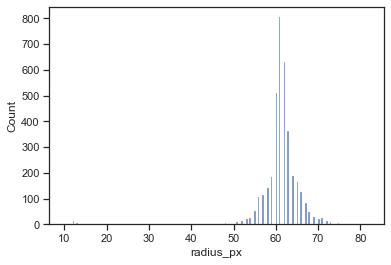

In [44]:
plt.figure()
sns.histplot(data=data_all, x="radius_px")

In [45]:
# Filter the data based on radius_px
# It will remove outlined nuclei

filtered_data_1 = data_all["radius_px"]>40
new_data = data_all.loc[filtered_data_1, ]

In [46]:
new_data.shape

(3695, 40)

In [47]:
# Additional filtering to remove overlaping  measurements

filtered_data_2 = new_data["filtered"]==True
new_data_2 = new_data.loc[filtered_data_2, ]

In [48]:
new_data_2.shape

(3361, 40)

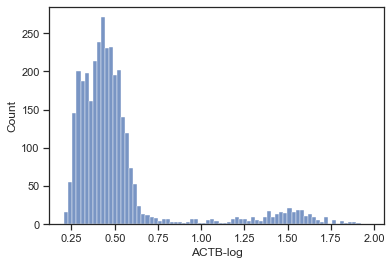

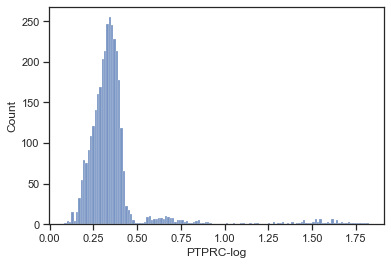

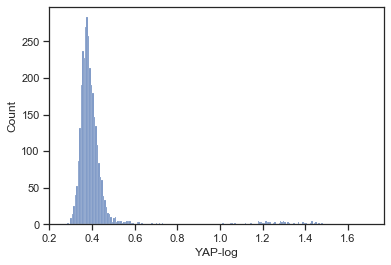

In [49]:
# For threshold selection:
plt.figure()
sns.histplot(data=new_data_2, x="ACTB-log")
plt.figure()
sns.histplot(data=new_data_2, x="PTPRC-log")
plt.figure()
sns.histplot(data=new_data_2, x="YAP-log")

In [50]:
# Add additional column with marker name

thresholds = dict()
thresholds["ACTB-log"] = 1.05
thresholds["PTPRC-log"] = 1.1
thresholds["YAP-log"] = 0.9

new_data_2['Marker'] = 'Empty'

new_data_2.loc[new_data_2["ACTB-log"] > thresholds["ACTB-log"], "Marker"] = 'ACTB'
new_data_2.loc[new_data_2["YAP-log"] > thresholds["YAP-log"], "Marker"] = 'YAP'
new_data_2.loc[new_data_2["PTPRC-log"] > thresholds["PTPRC-log"], "Marker"] = 'PTPRC'
new_data_2.loc[(new_data_2["ACTB-log"] > thresholds["ACTB-log"]) & (new_data_2["PTPRC-log"] > thresholds["PTPRC-log"]), "Marker"] = 'ACTB and PTPRC'
new_data_2.loc[(new_data_2["ACTB-log"] > thresholds["ACTB-log"]) & (new_data_2["YAP-log"] > thresholds["YAP-log"]), "Marker"] = 'ACTB and YAP'
new_data_2.loc[(new_data_2["PTPRC-log"] > thresholds["PTPRC-log"]) & (new_data_2["YAP-log"] > thresholds["YAP-log"]), "Marker"] = 'PTPRC and YAP'
new_data_2.loc[(new_data_2["ACTB-log"] > thresholds["ACTB-log"]) & (new_data_2["YAP-log"] > thresholds["YAP-log"]) & (new_data_2["PTPRC-log"] > thresholds["PTPRC-log"]), "Marker"] = 'ACTB, PTPRC and YAP'


In [51]:
new_data_2["Marker"].unique()

array(['Empty', 'ACTB', 'ACTB and PTPRC', 'ACTB and YAP', 'YAP',
       'ACTB, PTPRC and YAP'], dtype=object)

In [52]:
# Add additional column describing the presence of marker and nuclei


new_data_2['Final marker'] = 'Empty'

new_data_2.loc[(new_data_2["Marker"] == "Empty") & (new_data_2["class"] == "Nucleus"), "Final marker"] = "Nuclei"

new_data_2.loc[(new_data_2["Marker"] == "ACTB") & (new_data_2["class"] == "Empty"), "Final marker"] = "ACTB"
new_data_2.loc[(new_data_2["Marker"] == "PTPRC") & (new_data_2["class"] == "Empty"), "Final marker"] = "PTPRC"
new_data_2.loc[(new_data_2["Marker"] == "YAP") & (new_data_2["class"] == "Empty"), "Final marker"] = "YAP"

new_data_2.loc[(new_data_2["Marker"] == "ACTB and PTPRC") & (new_data_2["class"] == "Empty"), "Final marker"] = "ACTB & PTPRC"
new_data_2.loc[(new_data_2["Marker"] == "ACTB and YAP") & (new_data_2["class"] == "Empty"), "Final marker"] = "ACTB & YAP"
new_data_2.loc[(new_data_2["Marker"] == "ACTB, PTPRC and YAP") & (new_data_2["class"] == "Empty"), "Final marker"] = "ACTB,PTPRC & YAP"
new_data_2.loc[(new_data_2["Marker"] == "PTPRC and YAP") & (new_data_2["class"] == "Empty"), "Final marker"] = "PTPRC & YAP"

new_data_2.loc[(new_data_2["Marker"] == "ACTB") & (new_data_2["class"] == "Nucleus"), "Final marker"] = "ACTB & Nuclei"
new_data_2.loc[(new_data_2["Marker"] == "PTPRC") & (new_data_2["class"] == "Nucleus"), "Final marker"] = "PTPRC & Nuclei"
new_data_2.loc[(new_data_2["Marker"] == "YAP") & (new_data_2["class"] == "Nucleus"), "Final marker"] = "YAP & Nuclei"

new_data_2.loc[(new_data_2["Marker"] == "ACTB and PTPRC") & (new_data_2["class"] == "Nucleus"), "Final marker"] = "ACTB,PTPRC & Nuclei"
new_data_2.loc[(new_data_2["Marker"] == "ACTB and YAP") & (new_data_2["class"] == "Nucleus"), "Final marker"] = "ACTB,YAP & Nuclei"
new_data_2.loc[(new_data_2["Marker"] == "ACTB, PTPRC and YAP") & (new_data_2["class"] == "Nucleus"), "Final marker"] = "ACTB,PTPRC,YAP & Nuclei"
new_data_2.loc[(new_data_2["Marker"] == "PTPRC and YAP") & (new_data_2["class"] == "Nucleus"), "Final marker"] = "PTPRC,YAP & Nuclei"

new_data_2.shape
new_data_2["Final marker"].unique()

array(['Empty', 'ACTB', 'ACTB,PTPRC & Nuclei', 'ACTB,YAP & Nuclei',
       'ACTB & Nuclei', 'YAP & Nuclei', 'ACTB,PTPRC,YAP & Nuclei',
       'Nuclei', 'ACTB & YAP'], dtype=object)

In [53]:
# This step will help to hidden empty capsules and show mony ACTB positive capsules

new_data_2['emptyfirst'] = new_data_2['Final marker'] == 'Nuclei'
new_data_2.tail(3)
new_data_2.sort_values(by='emptyfirst',inplace=True,ascending=False)

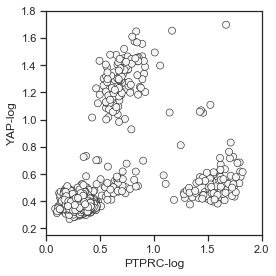

In [54]:
# Plot all microcapsules

X0, X1 = 0, 2.0
Y0, Y1 = 0.15, 1.8

color_dict = {'ACTB':'whitesmoke',
              'PTPRC':'whitesmoke',
              'YAP': 'whitesmoke',
              
              'ACTB & Nuclei': 'whitesmoke',
              'PTPRC & Nuclei': 'whitesmoke',
              'YAP & Nuclei':'whitesmoke',
              
              'ACTB & PTPRC': 'whitesmoke',
              'ACTB & YAP': 'whitesmoke',
              'ACTB,PTPRC & YAP': 'whitesmoke',
           
              
              'ACTB,PTPRC & Nuclei': 'whitesmoke',
              'ACTB,YAP & Nuclei': 'whitesmoke',
              'ACTB,PTPRC,YAP & Nuclei': 'whitesmoke',
              
              'Empty': 'whitesmoke',
              'Nuclei': 'whitesmoke'}


fig, axes = plt.subplots(1, 1, figsize=(4, 4))
plt.xlim(X0,X1)
plt.ylim(Y0,Y1)

sns.scatterplot(data=new_data_2, x="PTPRC-log", y="YAP-log", hue = 'Final marker', palette=color_dict, legend=False, edgecolor="k", s=50)

plt.tight_layout()

plt.savefig("All_microcapsules.pdf", format="pdf", dpi=300)
plt.savefig("All_microcapsules.png", format="png", dpi=300)
plt.savefig("All_microcapsules.svg", format="svg", dpi=300)

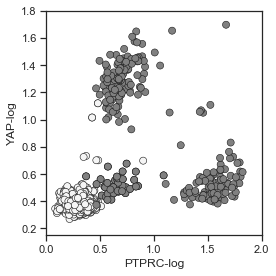

In [55]:
# Plot all microcapsules on scatterplot
# Color microcapsules with nuclei

X0, X1 = 0, 2.0
Y0, Y1 = 0.15, 1.8

color_dict = {'ACTB':'whitesmoke',
              'PTPRC':'whitesmoke',
              'YAP': 'whitesmoke',
              
              'ACTB & Nuclei': 'gray',
              'PTPRC & Nuclei': 'gray',
              'YAP & Nuclei':'gray',
              
              'ACTB & PTPRC': 'whitesmoke',
              'ACTB & YAP': 'whitesmoke',
              'ACTB,PTPRC & YAP': 'whitesmoke',
              
              'ACTB,PTPRC & Nuclei': 'gray',
              'ACTB,YAP & Nuclei': 'gray',
              'ACTB,PTPRC,YAP & Nuclei': 'gray',
              
              'Empty': 'whitesmoke',
              'Nuclei': 'gray'}


fig, axes = plt.subplots(1, 1, figsize=(4, 4))
plt.xlim(X0,X1)
plt.ylim(Y0,Y1)

sns.scatterplot(data=new_data_2, x="PTPRC-log", y="YAP-log", hue = 'Final marker', palette=color_dict, legend=False, edgecolor="k", s=50)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,PTPRC & YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "PTPRC"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & PTPRC"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

plt.tight_layout()

plt.savefig("Nuclei.pdf", format="pdf", dpi=300)
plt.savefig("Nuclei.png", format="png", dpi=300)
plt.savefig("Nuclei.svg", format="svg", dpi=300)

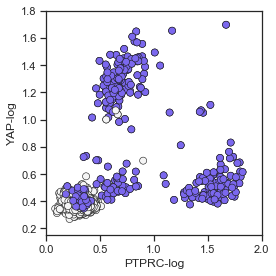

In [56]:
# Plot all microcapsules on scatterplot
# Color microcapsules with ACTB

X0, X1 = 0, 2.0
Y0, Y1 = 0.15, 1.8

color_dict = {'ACTB':'mediumslateblue',
              'PTPRC':'whitesmoke',
              'YAP': 'whitesmoke',
              
              'ACTB & Nuclei': 'mediumslateblue',
              'PTPRC & Nuclei': 'whitesmoke',
              'YAP & Nuclei':'whitesmoke',
              
              'ACTB & PTPRC': 'mediumslateblue',
              'ACTB & YAP': 'mediumslateblue',
              'ACTB,PTPRC & YAP': 'mediumslateblue',
              
              'ACTB,PTPRC & Nuclei': 'mediumslateblue',
              'ACTB,YAP & Nuclei': 'mediumslateblue',
              'ACTB,PTPRC,YAP & Nuclei': 'mediumslateblue',
              
              'Empty': 'whitesmoke',
              'Nuclei': 'whitesmoke'}


fig, axes = plt.subplots(1, 1, figsize=(4, 4))
plt.xlim(X0,X1)
plt.ylim(Y0,Y1)

sns.scatterplot(data=new_data_2, x="PTPRC-log", y="YAP-log", hue = 'Final marker', palette=color_dict, legend=False, edgecolor="k", s=50)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & PTPRC"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,PTPRC & YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,PTPRC & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,YAP & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,PTPRC,YAP & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "YAP & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "PTPRC"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "PTPRC & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

plt.tight_layout()

plt.savefig("ACTB.pdf", format="pdf", dpi=300)
plt.savefig("ACTB.png", format="png", dpi=300)
plt.savefig("ACTB.svg", format="svg", dpi=300)

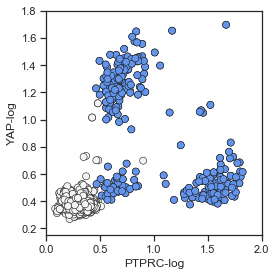

In [57]:
# Plot all microcapsules on scatterplot
# Color microcapsules with live cells

X0, X1 = 0, 2.0
Y0, Y1 = 0.15, 1.8

color_dict = {'ACTB':'whitesmoke',
              'PTPRC':'whitesmoke',
              'YAP': 'whitesmoke',
              
              'ACTB & Nuclei': 'cornflowerblue',
              'PTPRC & Nuclei': 'cornflowerblue',
              'YAP & Nuclei':'cornflowerblue',
              
              'ACTB & PTPRC': 'whitesmoke',
              'ACTB & YAP': 'whitesmoke',
              'ACTB,PTPRC & YAP': 'whitesmoke',
              
              'ACTB,PTPRC & Nuclei': 'cornflowerblue',
              'ACTB,YAP & Nuclei': 'cornflowerblue',
              'ACTB,PTPRC,YAP & Nuclei': 'cornflowerblue',
              
              'Empty': 'whitesmoke',
              'Nuclei': 'whitesmoke'}


fig, axes = plt.subplots(1, 1, figsize=(4, 4))
plt.xlim(X0,X1)
plt.ylim(Y0,Y1)

sns.scatterplot(data=new_data_2, x="PTPRC-log", y="YAP-log", hue = 'Final marker', palette=color_dict, legend=False, edgecolor="k", s=50)


sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,PTPRC & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,YAP & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,PTPRC,YAP & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "YAP & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "PTPRC"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & PTPRC"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "PTPRC & Nucei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

plt.tight_layout()

plt.savefig("Live.pdf", format="pdf", dpi=300)
plt.savefig("Live.png", format="png", dpi=300)
plt.savefig("Live.svg", format="svg", dpi=300)

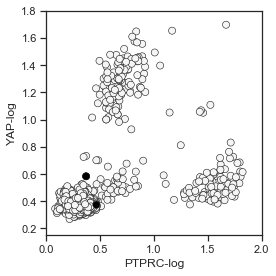

In [58]:
# Plot all capsules on scatterplot
# Color dead cells

X0, X1 = 0, 2.0
Y0, Y1 = 0.15, 1.8

color_dict = {'ACTB':'whitesmoke',
              'PTPRC':'whitesmoke',
              'YAP': 'whitesmoke',
              
              'ACTB & Nuclei': 'whitesmoke',
              'PTPRC & Nuclei': 'whitesmoke',
              'YAP & Nuclei':'whitesmoke',
              
              'ACTB & PTPRC': 'whitesmoke',
              'ACTB & YAP': 'whitesmoke',
              'ACTB,PTPRC & YAP': 'whitesmoke',
              
              'ACTB,PTPRC & Nuclei': 'whitesmoke',
              'ACTB,YAP & Nuclei': 'whitesmoke',
              'ACTB,PTPRC,YAP & Nuclei': 'whitesmoke',
              
              'Empty': 'whitesmoke',
              'Nuclei': 'black'}


fig, axes = plt.subplots(1, 1, figsize=(4, 4))
plt.xlim(X0,X1)
plt.ylim(Y0,Y1)

sns.scatterplot(data=new_data_2, x="PTPRC-log", y="YAP-log", hue = 'Final marker', palette=color_dict, legend=False, edgecolor="k", s=50)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "PTPRC & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "YAP & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

plt.tight_layout()

plt.savefig("Dead.pdf", format="pdf", dpi=300)
plt.savefig("Dead.png", format="png", dpi=300)
plt.savefig("Dead.svg", format="svg", dpi=300)

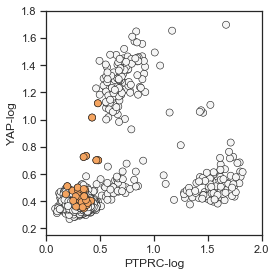

In [59]:
# Plot all capsules on scatterplot
# Color capsules with ambient RNA

X0, X1 = 0, 2.0
Y0, Y1 = 0.15, 1.8

color_dict = {'ACTB':'sandybrown',
              'PTPRC':'sandybrown',
              'YAP': 'sandybrown',
              
              'ACTB & Nuclei': 'whitesmoke',
              'PTPRC & Nuclei': 'whitesmoke',
              'YAP & Nuclei':'whitesmoke',
              
              'ACTB & PTPRC': 'sandybrown',
              'ACTB & YAP': 'sandybrown',
              'ACTB,PTPRC & YAP': 'sandybrown',
              
              'ACTB,PTPRC & Nuclei': 'whitesmoke',
              'ACTB,YAP & Nuclei': 'whitesmoke',
              'ACTB,PTPRC,YAP & Nuclei': 'whitesmoke',
              
              'Empty': 'whitesmoke',
              'Nuclei': 'whitesmoke'}

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
plt.xlim(X0,X1)
plt.ylim(Y0,Y1)

sns.scatterplot(data=new_data_2, x="PTPRC-log", y="YAP-log", hue = 'Final marker', palette=color_dict, legend=False,edgecolor="k", s=50)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "PTPRC"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & PTPRC"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,PTPRC & YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

plt.tight_layout()

plt.savefig("Ambient.pdf", format="pdf", dpi=300)
plt.savefig("Ambient.png", format="png", dpi=300)
plt.savefig("Ambient.svg", format="svg", dpi=300)

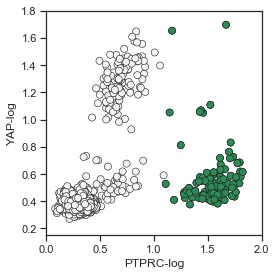

In [60]:
# Plot all capsules on scatterplot
# Color PTPRC positive capsules

X0, X1 = 0, 2.0
Y0, Y1 = 0.15, 1.8


color_dict = {'ACTB':'whitesmoke',
              'PTPRC':'seagreen',
              'YAP': 'whitesmoke',
              
              
              'ACTB & Nuclei': 'whitesmoke',
              'PTPRC & Nuclei': 'seagreen',
              'YAP & Nuclei':'whitesmoke',
              
              'ACTB & PTPRC': 'seagreen',
              'ACTB & YAP': 'whitesmoke',
              'ACTB,PTPRC & YAP': 'seagreen',
              
              'ACTB,PTPRC & Nuclei': 'seagreen',
              'ACTB,YAP & Nuclei': 'whitesmoke',
              'ACTB,PTPRC,YAP & Nuclei': 'seagreen',
              
              'Empty': 'whitesmoke',
              'Nuclei': 'whitesmoke'}

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
plt.xlim(X0,X1)
plt.ylim(Y0,Y1)

sns.scatterplot(data=new_data_2, x="PTPRC-log", y="YAP-log", hue = 'Final marker', palette=color_dict, legend=False,edgecolor="k", s=50)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "PTPRC"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "PTPRC & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & PTPRC"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,PTPRC & YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,PTPRC & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,PTPRC,YAP & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

plt.tight_layout()

plt.savefig("PTPRC.pdf", format="pdf", dpi=300)
plt.savefig("PTPRC.png", format="png", dpi=300)
plt.savefig("PTPRC.svg", format="svg", dpi=300)

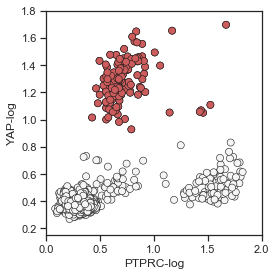

In [61]:
# Plot all capsules on scatterplot
# Color YAP positive capsules

X0, X1 = 0, 2.0
Y0, Y1 = 0.15, 1.8


color_dict = {'ACTB':'whitesmoke',
              'PTPRC':'whitesmoke',
              'YAP': 'indianred',
              
              
              'ACTB & Nuclei': 'whitesmoke',
              'PTPRC & Nuclei': 'whitesmoke',
              'YAP & Nuclei':'indianred',
              
              'ACTB & PTPRC': 'whitesmoke',
              'ACTB & YAP': 'indianred',
              'ACTB,PTPRC & YAP': 'indianred',
              
              'ACTB,PTPRC & Nuclei': 'whitesmoke',
              'ACTB,YAP & Nuclei': 'indianred',
              'ACTB,PTPRC,YAP & Nuclei': 'indianred',
              
              'Empty': 'whitesmoke',
              'Nuclei': 'whitesmoke'}

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
plt.xlim(X0,X1)
plt.ylim(Y0,Y1)

sns.scatterplot(data=new_data_2, x="PTPRC-log", y="YAP-log", hue = 'Final marker', palette=color_dict, legend=False,edgecolor="k", s=50)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "YAP & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,PTPRC & YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,YAP & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,PTPRC,YAP & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

plt.tight_layout()

plt.savefig("YAP.pdf", format="pdf", dpi=300)
plt.savefig("YAP.png", format="png", dpi=300)
plt.savefig("YAP.svg", format="svg", dpi=300)

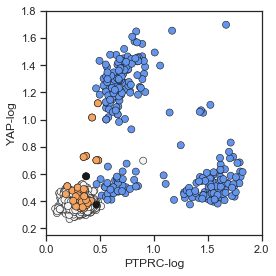

In [62]:
# Plot all capsules on scatterplot
# Color ambient RNA, live cells, dead cells


X0, X1 = 0, 2.0
Y0, Y1 = 0.15, 1.8

color_dict = {'ACTB':'sandybrown',
              'PTPRC':'sandybrown',
              'YAP': 'sandybrown',
              
              
              'ACTB & Nuclei': 'cornflowerblue',
              'PTPRC & Nuclei': 'cornflowerblue',
              'YAP & Nuclei':'cornflowerblue',
              
              'ACTB & PTPRC': 'sandybrown',
              'ACTB & YAP': 'sandybrown',
              'ACTB,PTPRC & YAP': 'sandybrown',
              
              'ACTB,PTPRC & Nuclei': 'cornflowerblue',
              'ACTB,YAP & Nuclei': 'cornflowerblue',
              'ACTB,PTPRC,YAP & Nuclei': 'cornflowerblue',
              
              'Empty': 'whitesmoke',
              'Nuclei': 'k'}

fig, axes = plt.subplots(1, 1, figsize=(4, 4))
plt.xlim(X0,X1)
plt.ylim(Y0,Y1)

sns.scatterplot(data=new_data_2, x="PTPRC-log", y="YAP-log", hue = 'Final marker', palette=color_dict, legend=False,edgecolor="k", s=50)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "PTPRC"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & PTPRC"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB & YAP"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "ACTB,PTPRC & PTPRC"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "PTPRC & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)
sns.scatterplot(data=new_data_2[new_data_2['Final marker'] == "YAP & Nuclei"], x="PTPRC-log", y="YAP-log", edgecolor="k",hue = 'Final marker',palette=color_dict, s=50, legend=False)

plt.tight_layout()

plt.savefig("Live_Dead_Cells_Ambient_Empty_Figure5_v4.pdf", format="pdf", dpi=300)
plt.savefig("Live_Dead_Cells_Ambient_Empty_Figure5_v4.png", format="png", dpi=300)
plt.savefig("Live_Dead_Cells_Ambient_Empty_Figure5_v4.svg", format="svg", dpi=300)

In [63]:
# Calculations of each fraction

In [64]:
sum(new_data_2["Final marker"]=="ACTB")

43

In [65]:
sum(new_data_2["Final marker"]=="PTPRC")

0

In [66]:
sum(new_data_2["Final marker"]=="YAP")

0

In [67]:
sum(new_data_2["Final marker"]=="ACTB & PTPRC")

0

In [68]:
sum(new_data_2["Final marker"]=="ACTB & YAP")

2

In [69]:
sum(new_data_2["Final marker"]=="ACTB,PTPRC & YAP")

0

In [70]:
sum(new_data_2["Final marker"]=="ACTB & Nuclei")

39

In [71]:
sum(new_data_2["Final marker"]=="PTPRC & Nuclei")

0

In [72]:
sum(new_data_2["Final marker"]=="YAP & Nuclei")

3

In [73]:
sum(new_data_2["Final marker"]=="ACTB,PTPRC & Nuclei")

92

In [74]:
sum(new_data_2["Final marker"]=="ACTB,YAP & Nuclei")

117

In [75]:
sum(new_data_2["Final marker"]=="ACTB,PTPRC,YAP & Nuclei")

7

In [76]:
sum(new_data_2["Final marker"]=="Nuclei")

2

In [77]:
sum(new_data_2["Final marker"]=="Empty")

3056

In [38]:
# # Cell sample and condition selection
cell_filtered = (new_data_2["Cell"] == "K562 and HEK293,") & (new_data_2["Condition"] == "30 cycles, + Nuclei")
selected_cell_condition = new_data_2.loc[cell_filtered, ]
selected_cell_condition.head() 
selected_cell_condition.shape

(3361, 43)

In [39]:
#Selection of ACTB, PTPRC, YAP or nuclei positive capsules
nuclei_filtered = (selected_cell_condition["ACTB-log"] > 1.05) | (selected_cell_condition["PTPRC-log"] > 1.1) |(selected_cell_condition["YAP-log"] > 0.9) | (selected_cell_condition["class"] == 'Nucleus')
data_final = selected_cell_condition.loc[nuclei_filtered, ]
data_final.head() 
print("Nuclei: ", sum((data_final["class"]=="Nucleus")), " all: ", sum((data_final["class"]=="Nucleus") | (data_final["class"]=="Empty")), " shape: ", data_final.shape)

Nuclei:  260  all:  305  shape:  (305, 43)
